<a href="https://colab.research.google.com/github/MohamedAbdeenM7/recommendation-system/blob/student1%2Fdata-preprocessing/student1_EDA_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Student 1 — Data Collection, Preprocessing & EDA
# Amazon Electronics Dataset — Ratings Only
# ============================================================

# ============================================================
# 1 Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# ============================================================
# 2 Google Drive
# ============================================================
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/recommendation-data/Electronics.csv'

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=['user_id', 'product_id', 'rating', 'timestamp']
)

print("✅ Data Loaded!")
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded!
Shape: (20994353, 4)


,user_id,product_id,rating,timestamp
0,0060009810,A1N070NS9CJQ2I,5.0,1026864000
1,0060009810,A3P0KRKOBQK1KN,5.0,1025913600
2,0060009810,A192HO2ICJ75VU,5.0,1025654400
3,0060009810,A2T278FKFL3BLT,4.0,1025395200
4,0060009810,A2ZUXVTW8RXBXW,5.0,1025222400


In [2]:
# ============================================================
# 3 Raw Data
# ============================================================
print("=" * 40)
print("📊 Basic Info:")
print("=" * 40)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique Users: {df['user_id'].nunique():,}")
print(f"Unique Products: {df['product_id'].nunique():,}")
print(f"Rating Range: {df['rating'].min()} - {df['rating'].max()}")
print("=" * 40)
print("\n📋 Data Types:")
print(df.dtypes)
print("\n❓ Missing Values:")
print(df.isnull().sum())
print("\n🔁 Duplicates:", df.duplicated().sum())

📊 Basic Info:
Rows: 20,994,353
Columns: 4
Unique Users: 756,489
Unique Products: 9,838,676
Rating Range: 1.0 - 5.0

📋 Data Types:
user_id        object
product_id     object
rating        float64
timestamp       int64
dtype: object

❓ Missing Values:
user_id       0
product_id    0
rating        0
timestamp     0
dtype: int64

🔁 Duplicates: 426262


In [3]:
# ============================================================
# 4 Cleaning
# ============================================================

# حذف الـ duplicates
df = df.drop_duplicates()
print(f"✅ After removing duplicates: {df.shape}")

# تحويل الـ timestamp لتاريخ
df['date'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.drop(columns=['timestamp'])
print("✅ Timestamp converted to date!")

# التأكد إن الـ ratings بين 1 و 5
df = df[df['rating'].between(1, 5)]
print(f"✅ After filtering ratings: {df.shape}")

df.head()

✅ After removing duplicates: (20568091, 4)
✅ Timestamp converted to date!
✅ After filtering ratings: (20568091, 4)


,user_id,product_id,rating,date
0,0060009810,A1N070NS9CJQ2I,5.0,2002-07-17
1,0060009810,A3P0KRKOBQK1KN,5.0,2002-07-06
2,0060009810,A192HO2ICJ75VU,5.0,2002-07-03
3,0060009810,A2T278FKFL3BLT,4.0,2002-06-30
4,0060009810,A2ZUXVTW8RXBXW,5.0,2002-06-28


In [4]:
# ============================================================
# 5 Filtering —  Active Users , Popular Products
# ============================================================

# Keep users with at least 5 ratings
user_counts = df['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index
df = df[df['user_id'].isin(active_users)]
print(f"✅ After filtering active users: {df.shape}")

# Keep products with at least 5 ratings
product_counts = df['product_id'].value_counts()
popular_products = product_counts[product_counts >= 5].index
df = df[df['product_id'].isin(popular_products)]
print(f"✅ After filtering popular products: {df.shape}")

print(f"\n📊 Final Stats:")
print(f"Unique Users: {df['user_id'].nunique():,}")
print(f"Unique Products: {df['product_id'].nunique():,}")
print(f"Total Ratings: {df.shape[0]:,}")

✅ After filtering active users: (19749352, 4)
✅ After filtering popular products: (6912295, 4)

📊 Final Stats:
Unique Users: 282,907
Unique Products: 746,912
Total Ratings: 6,912,295


/tmp/ipykernel_21230/11514455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, ax=axes[0, 0], palette='viridis')


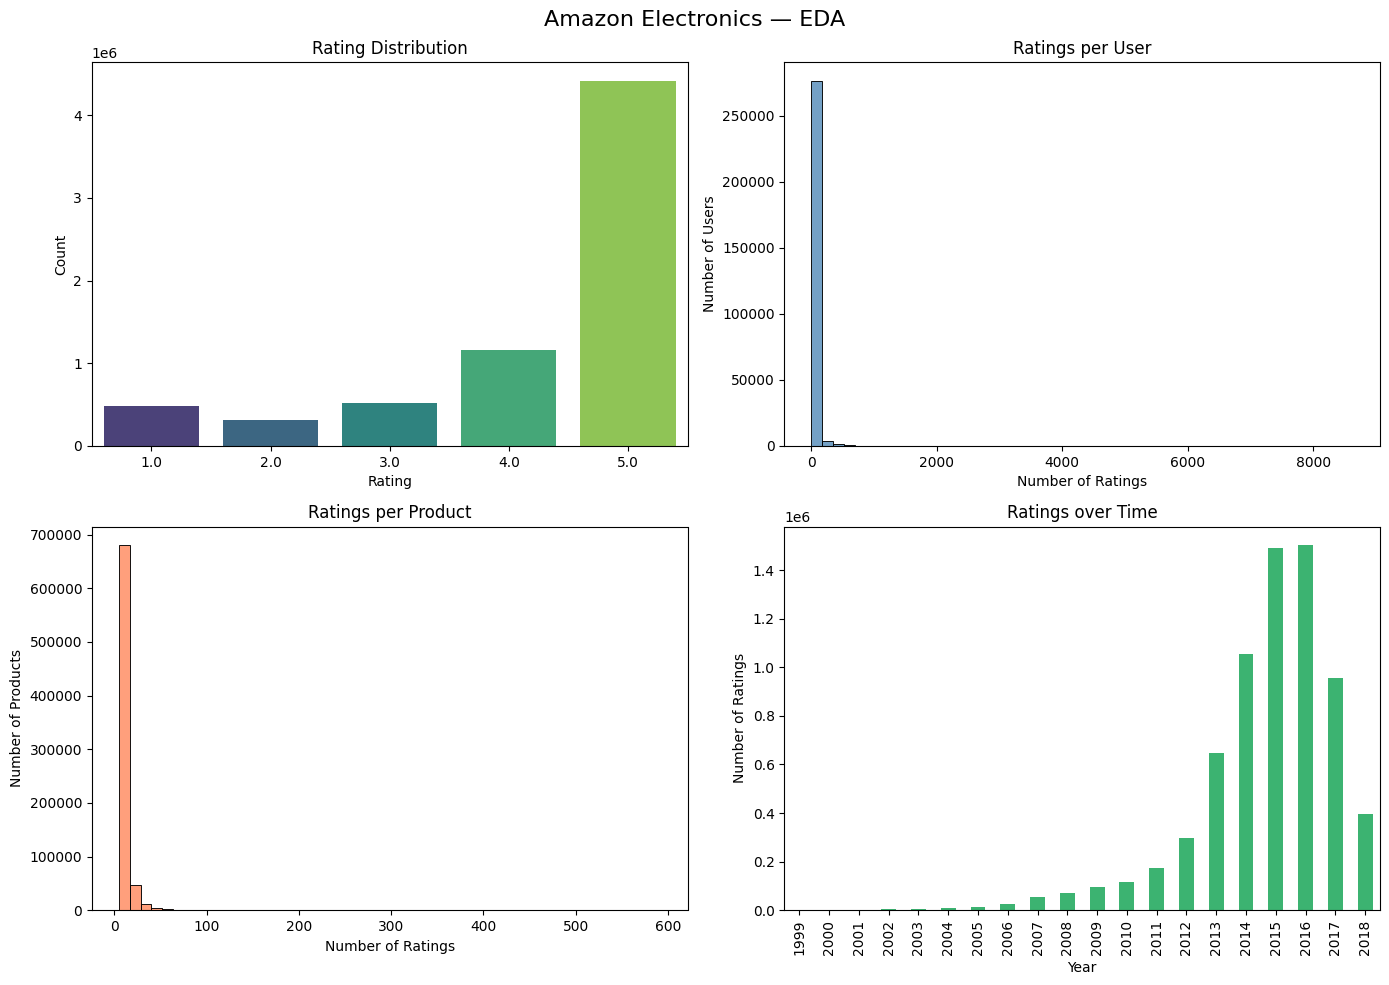

✅ EDA plots saved!


In [5]:
# ============================================================
# الخطوة 6: EDA — تحليل البيانات
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Amazon Electronics — EDA', fontsize=16)

# 1 Ratings
sns.countplot(x='rating', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# 2 Ratings For User
user_activity = df['user_id'].value_counts()
sns.histplot(user_activity, bins=50, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Ratings per User')
axes[0, 1].set_xlabel('Number of Ratings')
axes[0, 1].set_ylabel('Number of Users')

# 3 Ratings For Product
product_activity = df['product_id'].value_counts()
sns.histplot(product_activity, bins=50, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Ratings per Product')
axes[1, 0].set_xlabel('Number of Ratings')
axes[1, 0].set_ylabel('Number of Products')

# 4. Ratings over Time
df.groupby(df['date'].dt.year)['rating'].count().plot(
    kind='bar', ax=axes[1, 1], color='mediumseagreen'
)
axes[1, 1].set_title('Ratings over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.savefig('eda_report.png')
plt.show()
print("✅ EDA plots saved!")

In [6]:
# ============================================================
# 7 Sparsity
# ============================================================

n_users = df['user_id'].nunique()
n_products = df['product_id'].nunique()
n_ratings = df.shape[0]

sparsity = 1 - (n_ratings / (n_users * n_products))

print("=" * 40)
print(f"👥 Users: {n_users:,}")
print(f"📦 Products: {n_products:,}")
print(f"⭐ Ratings: {n_ratings:,}")
print(f"🕳️ Sparsity: {sparsity:.4%}")
print("=" * 40)

👥 Users: 282,907
📦 Products: 746,912
⭐ Ratings: 6,912,295
🕳️ Sparsity: 99.9967%


In [7]:
# ============================================================
# 8 Processing
# ============================================================

PROCESSED_PATH = '/content/drive/MyDrive/recommendation-data/ratings_clean.csv'
df.to_csv(PROCESSED_PATH, index=False)
print(f"✅ Clean data saved to Drive!")
print(f"📁 Path: {PROCESSED_PATH}")
print(f"📊 Shape: {df.shape}")

✅ Clean data saved to Drive!
📁 Path: /content/drive/MyDrive/recommendation-data/ratings_clean.csv
📊 Shape: (6912295, 4)


In [8]:
import os
from google.colab import userdata

%cd /content/recommendation-system

token = userdata.get('GITHUB_TOKEN')
os.environ['TOKEN'] = token

!git config --global user.email "MohamedAbdeenM7@gmail.com"
!git config --global user.name "Student1"

!git checkout student1/data-preprocessing

!cp /content/eda_report.png notebooks/

!git remote set-url origin https://$TOKEN@github.com/MohamedAbdeenM7/recommendation-system.git
!git add .
!git commit -m "✅ M1: EDA and preprocessing complete"
!git push origin student1/data-preprocessing

print("✅ Pushed to GitHub!")
print("🔗 https://github.com/MohamedAbdeenM7/recommendation-system")

/content/recommendation-system
Already on 'student1/data-preprocessing'
On branch student1/data-preprocessing
nothing to commit, working tree clean
Everything up-to-date
✅ Pushed to GitHub!
🔗 https://github.com/MohamedAbdeenM7/recommendation-system
